# 🛰️ Project Sentinel: Hazardous Asteroid Prediction AI

**NASA Planetary Defense Coordination Office — Capstone Project**

**Objective:** Build a supervised machine learning system that predicts whether a Near Earth Object (NEO) is **Hazardous** or **Non-Hazardous**, based on its physical and orbital characteristics (absolute magnitude, estimated diameter, relative velocity, and miss distance).

This notebook progresses through six phases:
1. Data Preparation & Preprocessing
2. Exploratory Data Analysis
3. Feature Engineering & Selection
4. Model Development
5. Explainability & Visualization
6. Deployment

---

## 0. Setup — Import Libraries

We only rely on widely available libraries (`pandas`, `numpy`, `matplotlib`, `seaborn`, `scikit-learn`, `joblib`) so this notebook runs on any standard Python/Jupyter installation without extra installs.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve, precision_recall_curve, ConfusionMatrixDisplay
)

import joblib

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries loaded successfully.")

Libraries loaded successfully.


---
## Phase 1: Data Preparation & Preprocessing

### 1.1 Load the Dataset

In [3]:
# Load the NASA NEO dataset
df = pd.read_csv("neo__3_.csv")

print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (90836, 10)


,id,name,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,orbiting_body,sentry_object,absolute_magnitude,hazardous
0,2162635,162635 (2000 SS164),1.198271,2.679415,13569.249224,5.483974e+07,Earth,False,16.73,False
1,2277475,277475 (2005 WK4),0.265800,0.594347,73588.726663,6.143813e+07,Earth,False,20.00,True
2,2512244,512244 (2015 YE18),0.722030,1.614507,114258.692129,4.979872e+07,Earth,False,17.83,False
3,3596030,(2012 BV13),0.096506,0.215794,24764.303138,2.543497e+07,Earth,False,22.20,False
4,3667127,(2014 GE35),0.255009,0.570217,42737.733765,4.627557e+07,Earth,False,20.09,True


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 90836 entries, 0 to 90835
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  90836 non-null  int64  
 1   name                90836 non-null  str    
 2   est_diameter_min    90836 non-null  float64
 3   est_diameter_max    90836 non-null  float64
 4   relative_velocity   90836 non-null  float64
 5   miss_distance       90836 non-null  float64
 6   orbiting_body       90836 non-null  str    
 7   sentry_object       90836 non-null  bool   
 8   absolute_magnitude  90836 non-null  float64
 9   hazardous           90836 non-null  bool   
dtypes: bool(2), float64(5), int64(1), str(2)
memory usage: 7.1 MB


In [5]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,90836.0,NaN,NaN,NaN,14382878.05216,20872018.353893,2000433.0,3448110.0,3748362.0,3884023.0,54275914.0
name,90836,27423,277810 (2006 FV35),43,NaN,NaN,NaN,NaN,NaN,NaN,NaN
est_diameter_min,90836.0,NaN,NaN,NaN,0.127432,0.298511,0.000609,0.019256,0.048368,0.143402,37.89265
est_diameter_max,90836.0,NaN,NaN,NaN,0.284947,0.667491,0.001362,0.043057,0.108153,0.320656,84.730541
relative_velocity,90836.0,NaN,NaN,NaN,48066.918918,25293.296961,203.346433,28619.020645,44190.11789,62923.604633,236990.128088
miss_distance,90836.0,NaN,NaN,NaN,37066546.030422,22352040.59919,6745.532516,17210820.235765,37846579.263426,56548996.451399,74798651.452197
orbiting_body,90836,1,Earth,90836,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sentry_object,90836,1,False,90836,NaN,NaN,NaN,NaN,NaN,NaN,NaN
absolute_magnitude,90836.0,NaN,NaN,NaN,23.527103,2.894086,9.23,21.34,23.7,25.7,33.2
hazardous,90836,2,False,81996,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 1.2 Handle Missing Values

In [6]:
# Check for missing values
missing = df.isnull().sum()
print("Missing values per column:")
print(missing)

# Check for duplicate rows
print("\nDuplicate rows:", df.duplicated().sum())

Missing values per column:
id                    0
name                  0
est_diameter_min      0
est_diameter_max      0
relative_velocity     0
miss_distance         0
orbiting_body         0
sentry_object         0
absolute_magnitude    0
hazardous             0
dtype: int64

Duplicate rows: 0


In [7]:
# The dataset has no missing values, but we still write a generic, defensive routine
# so the pipeline stays robust if new data (with missing values) arrives in production.

numeric_cols_all = df.select_dtypes(include=[np.number]).columns.tolist()

for col in numeric_cols_all:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

# Drop duplicate rows, if any
before = df.shape[0]
df = df.drop_duplicates().reset_index(drop=True)
after = df.shape[0]
print(f"Removed {before - after} duplicate rows. New shape: {df.shape}")

Removed 0 duplicate rows. New shape: (90836, 10)


### 1.3 Remove Unnecessary Attributes

- `id` and `name` are unique identifiers with no predictive value.
- `orbiting_body` and `sentry_object` are constant across the entire dataset (every object orbits Earth and none are flagged Sentry objects here), so they carry **zero information** for the model.

In [8]:
for col in ["orbiting_body", "sentry_object"]:
    print(col, "->", df[col].unique())

orbiting_body -> <ArrowStringArray>
['Earth']
Length: 1, dtype: str
sentry_object -> [False]


In [9]:
columns_to_drop = ["id", "name", "orbiting_body", "sentry_object"]
df = df.drop(columns=[c for c in columns_to_drop if c in df.columns])
print("Remaining columns:", list(df.columns))
df.head()

Remaining columns: ['est_diameter_min', 'est_diameter_max', 'relative_velocity', 'miss_distance', 'absolute_magnitude', 'hazardous']


,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,absolute_magnitude,hazardous
0,1.198271,2.679415,13569.249224,5.483974e+07,16.73,False
1,0.265800,0.594347,73588.726663,6.143813e+07,20.00,True
2,0.722030,1.614507,114258.692129,4.979872e+07,17.83,False
3,0.096506,0.215794,24764.303138,2.543497e+07,22.20,False
4,0.255009,0.570217,42737.733765,4.627557e+07,20.09,True


### 1.4 Encode the Target Variable

`hazardous` is boolean (`True`/`False`). We encode it as `1` (Hazardous) / `0` (Non-Hazardous) for scikit-learn.

In [10]:
df["hazardous"] = df["hazardous"].astype(int)
df["hazardous"].value_counts()

hazardous
0    81996
1     8840
Name: count, dtype: int64

### 1.5 Feature Scaling

There are no other categorical variables to encode — every remaining feature is numeric. Numerical scaling (`StandardScaler`) will be applied **after** the train/test split in Phase 4, to avoid data leakage from the test set into training statistics.

---
## Phase 2: Exploratory Data Analysis

### 2.1 Class Distribution

hazardous
0    81996
1     8840
Name: count, dtype: int64
hazardous
0    90.268176
1     9.731824
Name: proportion, dtype: float64


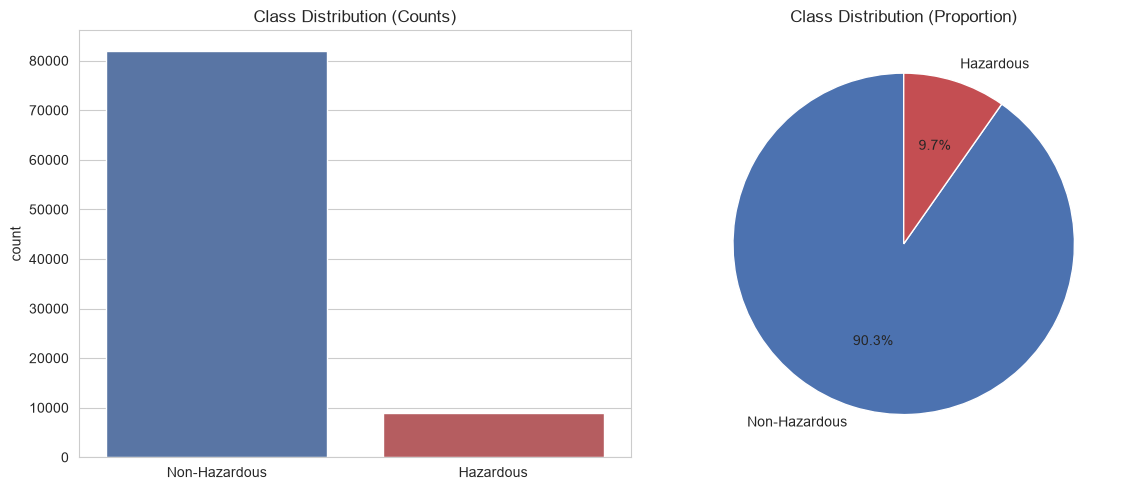


Only 9.73% of NEOs are hazardous -> this confirms a significant CLASS IMBALANCE problem.


In [11]:
class_counts = df["hazardous"].value_counts()
class_pct = df["hazardous"].value_counts(normalize=True) * 100

print(class_counts)
print(class_pct)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(x="hazardous", data=df, ax=axes[0], palette=["#4C72B0", "#C44E52"])
axes[0].set_xticklabels(["Non-Hazardous", "Hazardous"])
axes[0].set_title("Class Distribution (Counts)")
axes[0].set_xlabel("")

axes[1].pie(class_counts, labels=["Non-Hazardous", "Hazardous"], autopct="%1.1f%%",
            colors=["#4C72B0", "#C44E52"], startangle=90)
axes[1].set_title("Class Distribution (Proportion)")

plt.tight_layout()
plt.show()

print(f"\nOnly {class_pct[1]:.2f}% of NEOs are hazardous -> this confirms a significant CLASS IMBALANCE problem.")

### 2.2 Summary Statistics

In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
est_diameter_min,90836.0,1.274321e-01,2.985112e-01,0.000609,1.925551e-02,4.836765e-02,1.434019e-01,3.789265e+01
est_diameter_max,90836.0,2.849469e-01,6.674914e-01,0.001362,4.305662e-02,1.081534e-01,3.206564e-01,8.473054e+01
relative_velocity,90836.0,4.806692e+04,2.529330e+04,203.346433,2.861902e+04,4.419012e+04,6.292360e+04,2.369901e+05
miss_distance,90836.0,3.706655e+07,2.235204e+07,6745.532516,1.721082e+07,3.784658e+07,5.654900e+07,7.479865e+07
absolute_magnitude,90836.0,2.352710e+01,2.894086e+00,9.230000,2.134000e+01,2.370000e+01,2.570000e+01,3.320000e+01
hazardous,90836.0,9.731824e-02,2.963923e-01,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00


### 2.3 Feature Distributions

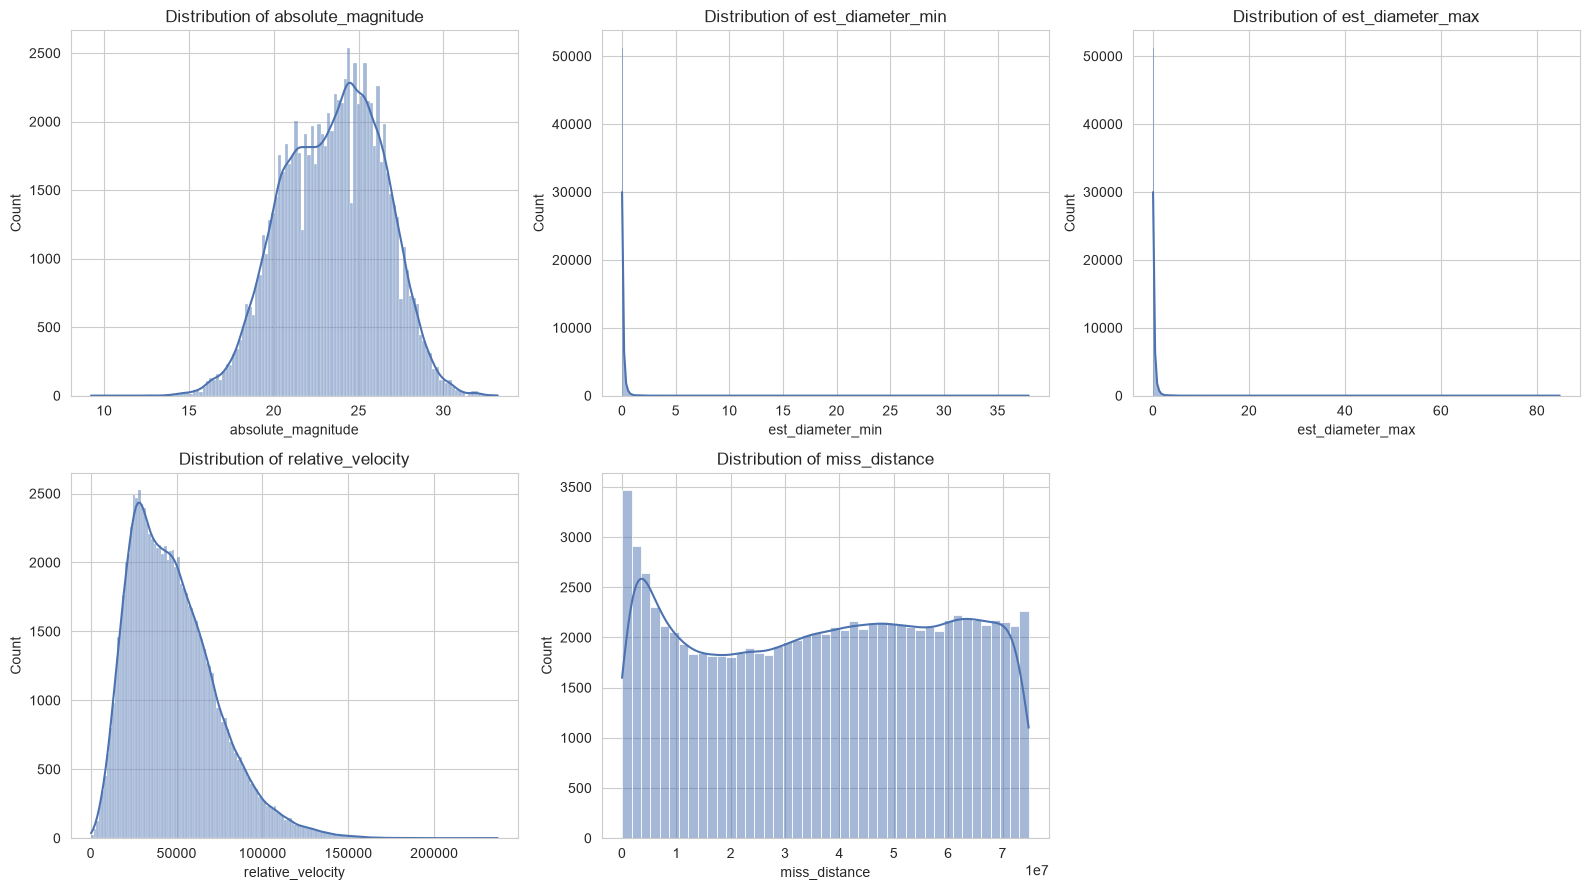

In [13]:
numeric_features = ["absolute_magnitude", "est_diameter_min", "est_diameter_max",
                     "relative_velocity", "miss_distance"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(numeric_features):
    sns.histplot(df[col], kde=True, ax=axes[i], color="#4C72B0")
    axes[i].set_title(f"Distribution of {col}")
axes[-1].axis("off")
plt.tight_layout()
plt.show()

### 2.4 Feature Relationships with Hazard Status (Boxplots)

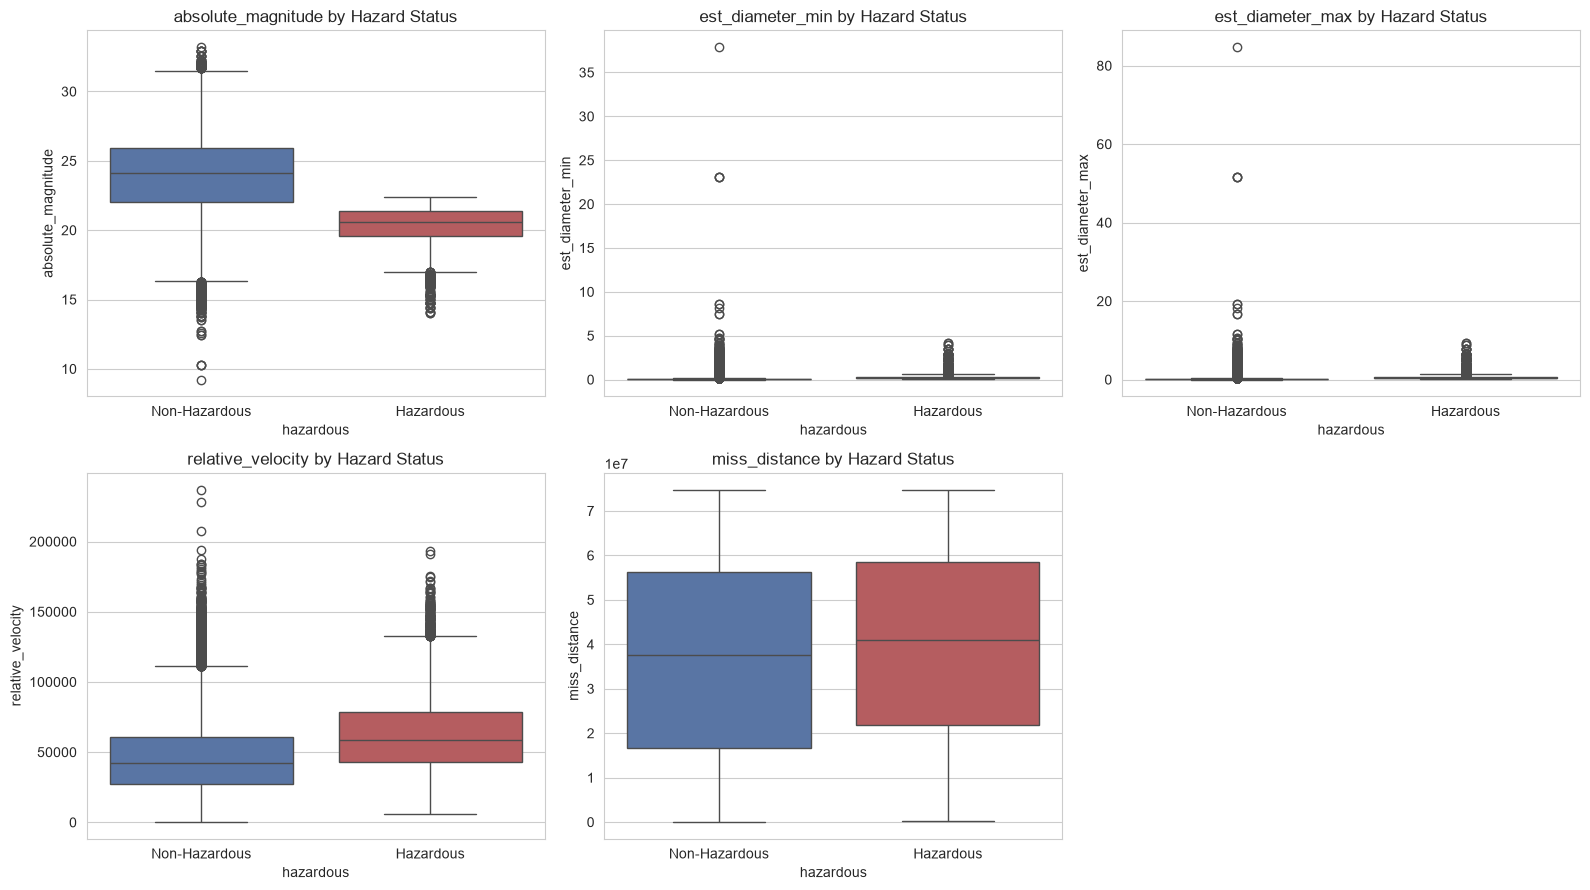

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(numeric_features):
    sns.boxplot(x="hazardous", y=col, data=df, ax=axes[i], palette=["#4C72B0", "#C44E52"])
    axes[i].set_xticklabels(["Non-Hazardous", "Hazardous"])
    axes[i].set_title(f"{col} by Hazard Status")
axes[-1].axis("off")
plt.tight_layout()
plt.show()

**Observations:**
- Hazardous asteroids tend to have a **lower absolute magnitude** (which, counter-intuitively, means they are **larger/brighter** objects — magnitude is an inverse brightness/size scale).
- Hazardous asteroids tend to have **larger estimated diameters**.
- Hazardous asteroids tend to travel at **higher relative velocities**.
- `miss_distance` alone is not a very clean separator — this confirms the assignment's **Multi-Factor Risk Assessment Challenge**: no single feature fully determines hazard status.

### 2.5 Correlation Analysis

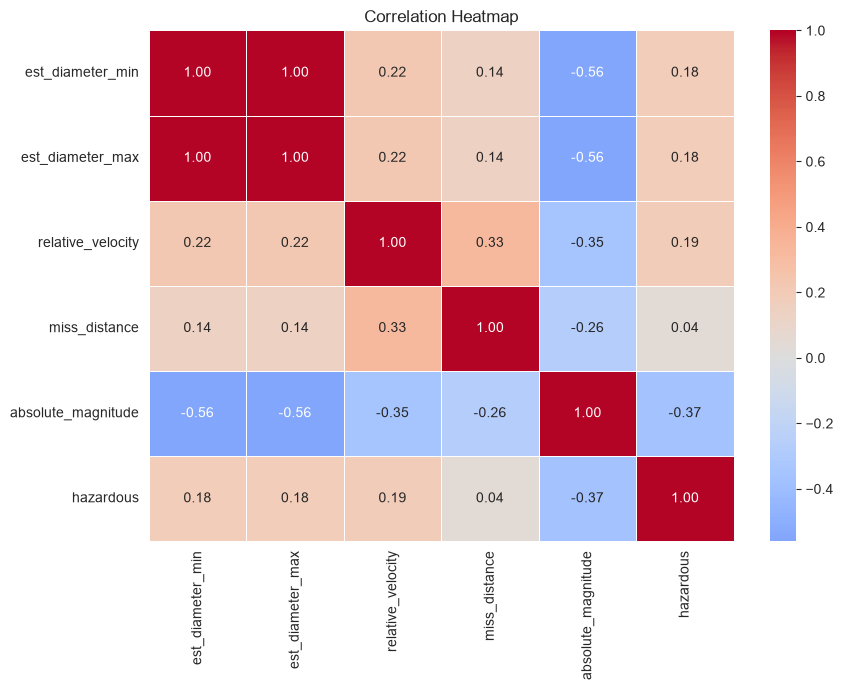

Correlation with target (hazardous):
hazardous             1.000000
relative_velocity     0.191185
est_diameter_max      0.183363
est_diameter_min      0.183363
miss_distance         0.042302
absolute_magnitude   -0.365267
Name: hazardous, dtype: float64


In [15]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

print("Correlation with target (hazardous):")
print(corr_matrix["hazardous"].sort_values(ascending=False))

**Key insight:** `est_diameter_min` and `est_diameter_max` are **perfectly correlated (1.00)** with each other — NASA derives both from the same absolute-magnitude/albedo formula, so they carry identical information. This redundancy will be addressed in Phase 3.

### 2.6 Bivariate Relationship: Velocity vs. Miss Distance vs. Diameter

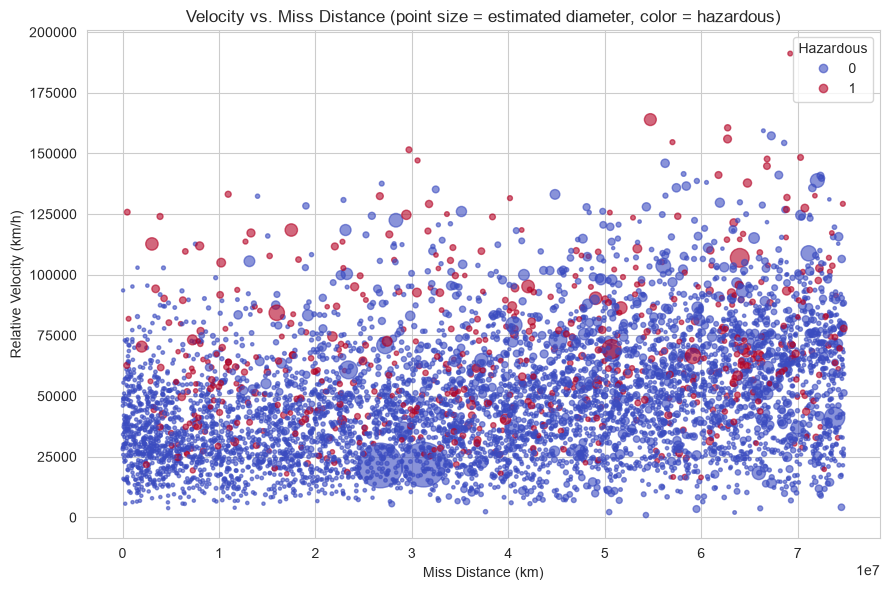

This illustrates the Feature Relationship Challenge: hazard depends on a NON-LINEAR
combination of size, speed, and distance — not any single variable in isolation.


In [16]:
plt.figure(figsize=(9, 6))
sample = df.sample(min(6000, len(df)), random_state=RANDOM_STATE)  # sample for readability
scatter = plt.scatter(
    sample["miss_distance"], sample["relative_velocity"],
    c=sample["hazardous"], cmap="coolwarm", alpha=0.6,
    s=sample["est_diameter_max"] * 20 + 5
)
plt.xlabel("Miss Distance (km)")
plt.ylabel("Relative Velocity (km/h)")
plt.title("Velocity vs. Miss Distance (point size = estimated diameter, color = hazardous)")
plt.legend(*scatter.legend_elements(), title="Hazardous")
plt.tight_layout()
plt.show()

print("This illustrates the Feature Relationship Challenge: hazard depends on a NON-LINEAR")
print("combination of size, speed, and distance — not any single variable in isolation.")

---
## Phase 3: Feature Engineering & Selection

### 3.1 Engineer New Features

- **`est_diameter_avg`** — average of min/max diameter (single size indicator).
- **`velocity_distance_ratio`** — a simple "approach risk" indicator: how fast the object is closing in relative to how far it currently is.

In [17]:
df["est_diameter_avg"] = (df["est_diameter_min"] + df["est_diameter_max"]) / 2
df["velocity_distance_ratio"] = df["relative_velocity"] / df["miss_distance"]

df[["est_diameter_min", "est_diameter_max", "est_diameter_avg",
    "relative_velocity", "miss_distance", "velocity_distance_ratio"]].head()

,est_diameter_min,est_diameter_max,est_diameter_avg,relative_velocity,miss_distance,velocity_distance_ratio
0,1.198271,2.679415,1.938843,13569.249224,5.483974e+07,0.000247
1,0.265800,0.594347,0.430073,73588.726663,6.143813e+07,0.001198
2,0.722030,1.614507,1.168268,114258.692129,4.979872e+07,0.002294
3,0.096506,0.215794,0.156150,24764.303138,2.543497e+07,0.000974
4,0.255009,0.570217,0.412613,42737.733765,4.627557e+07,0.000924


### 3.2 Remove Redundant Attributes

As shown in the Phase 2 correlation heatmap, `est_diameter_min` and `est_diameter_max` are perfectly correlated (r = 1.00). Keeping all three diameter-related columns would add redundant, collinear information without any new signal, and can destabilize model coefficients (especially for linear models) and distort feature-importance interpretation. We keep only `est_diameter_avg` as the representative size feature.

In [18]:
redundancy_check = df[["est_diameter_min", "est_diameter_max", "est_diameter_avg"]].corr()
print(redundancy_check)

features_to_drop = ["est_diameter_min", "est_diameter_max"]
print(f"\nDropping redundant features: {features_to_drop}")

                  est_diameter_min  est_diameter_max  est_diameter_avg
est_diameter_min               1.0               1.0               1.0
est_diameter_max               1.0               1.0               1.0
est_diameter_avg               1.0               1.0               1.0

Dropping redundant features: ['est_diameter_min', 'est_diameter_max']


### 3.3 Evaluate Feature Correlations & Mutual Information

We use **mutual information** (captures non-linear relationships too, unlike Pearson correlation) to rank candidate features against the target.

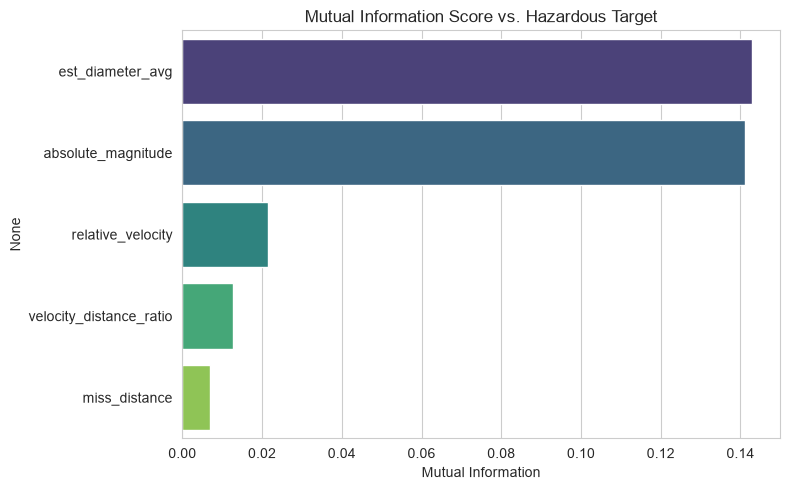

est_diameter_avg           0.142773
absolute_magnitude         0.141148
relative_velocity          0.021586
velocity_distance_ratio    0.012679
miss_distance              0.006874
dtype: float64


In [19]:
candidate_features = ["absolute_magnitude", "est_diameter_avg", "relative_velocity",
                      "miss_distance", "velocity_distance_ratio"]

X_candidate = df[candidate_features]
y_candidate = df["hazardous"]

mi_scores = mutual_info_classif(X_candidate, y_candidate, random_state=RANDOM_STATE)
mi_series = pd.Series(mi_scores, index=candidate_features).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=mi_series.values, y=mi_series.index, palette="viridis")
plt.title("Mutual Information Score vs. Hazardous Target")
plt.xlabel("Mutual Information")
plt.tight_layout()
plt.show()

print(mi_series)

### 3.4 Final Feature Matrix

All candidate features carry meaningful, non-redundant signal, so we keep all five for modeling.

In [20]:
FEATURE_COLS = ["absolute_magnitude", "est_diameter_avg", "relative_velocity",
                "miss_distance", "velocity_distance_ratio"]

X = df[FEATURE_COLS].copy()
y = df["hazardous"].copy()

print("Final feature matrix shape:", X.shape)
X.head()

Final feature matrix shape: (90836, 5)


,absolute_magnitude,est_diameter_avg,relative_velocity,miss_distance,velocity_distance_ratio
0,16.73,1.938843,13569.249224,5.483974e+07,0.000247
1,20.00,0.430073,73588.726663,6.143813e+07,0.001198
2,17.83,1.168268,114258.692129,4.979872e+07,0.002294
3,22.20,0.156150,24764.303138,2.543497e+07,0.000974
4,20.09,0.412613,42737.733765,4.627557e+07,0.000924


---
## Phase 4: Model Development

### 4.1 Train/Test Split

We use a **stratified** split so the (imbalanced) class ratio is preserved in both the training and testing sets.

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape, " | Test shape:", X_test.shape)
print("\nTrain class balance:\n", y_train.value_counts(normalize=True))
print("\nTest class balance:\n", y_test.value_counts(normalize=True))

Train shape: (72668, 5)  | Test shape: (18168, 5)

Train class balance:
 hazardous
0    0.902681
1    0.097319
Name: proportion, dtype: float64

Test class balance:
 hazardous
0    0.902686
1    0.097314
Name: proportion, dtype: float64


### 4.2 Feature Scaling

In [22]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete. Mean (train, ~0):", X_train_scaled.mean(axis=0).round(3))
print("Std  (train, ~1):", X_train_scaled.std(axis=0).round(3))

Scaling complete. Mean (train, ~0): [-0. -0. -0. -0. -0.]
Std  (train, ~1): [1. 1. 1. 1. 1.]


### 4.3 Handling Class Imbalance

Hazardous asteroids are only ~10% of the data. A naive model could get ~90% accuracy by *always* predicting "Non-Hazardous" — which is exactly the failure mode NASA cannot afford. We address this with:

1. **`class_weight="balanced"`** in every model — this penalizes misclassifying the minority (hazardous) class more heavily during training, without throwing away any data.
2. **Threshold tuning** in Phase 4.5 — adjusting the decision threshold to favor **recall** (catching true hazards) over raw accuracy, which is the right trade-off for a planetary-defense system (missing a real hazardous object is far costlier than a false alarm).
3. Evaluating with **Precision, Recall, F1, and ROC-AUC** instead of relying on accuracy alone.

In [23]:
# Baseline sanity check: what would a "predict everyone non-hazardous" model score?
baseline_preds = np.zeros_like(y_test)
print("Baseline 'always non-hazardous' accuracy:", accuracy_score(y_test, baseline_preds))
print("Baseline 'always non-hazardous' recall on hazardous class: 0.0  <-- completely useless for NASA")

Baseline 'always non-hazardous' accuracy: 0.9026860413914575
Baseline 'always non-hazardous' recall on hazardous class: 0.0  <-- completely useless for NASA


### 4.4 Train Multiple Classification Models

In [24]:
models = {
    "Logistic Regression": LogisticRegression(class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(class_weight="balanced", max_depth=10, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(class_weight="balanced_subsample", n_estimators=200,
                                             random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

results = []
fitted_models = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    proba = model.predict_proba(X_test_scaled)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1-Score": f1_score(y_test, preds),
        "ROC-AUC": roc_auc_score(y_test, proba),
    })
    fitted_models[name] = model

results_df = pd.DataFrame(results).sort_values("F1-Score", ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Decision Tree,0.796180,0.319530,0.968891,0.480572,0.904584
1,Logistic Regression,0.786052,0.304340,0.932127,0.458861,0.879451
2,Random Forest,0.915015,0.617647,0.332579,0.432353,0.931282
3,Gradient Boosting,0.914960,0.815864,0.162896,0.271570,0.921183


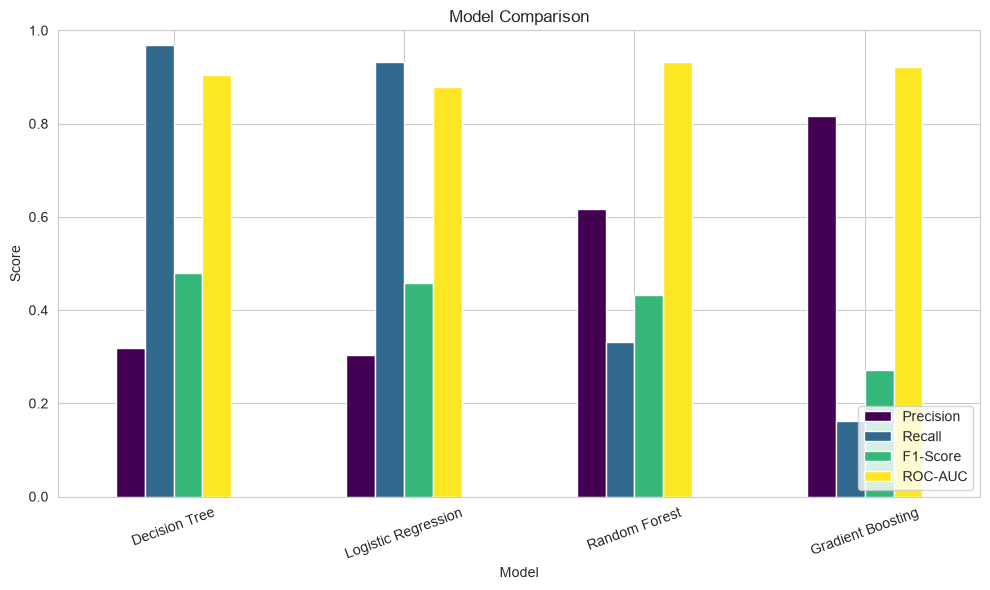

In [25]:
results_df.set_index("Model")[["Precision", "Recall", "F1-Score", "ROC-AUC"]].plot(
    kind="bar", figsize=(10, 6), colormap="viridis"
)
plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

### 4.5 Hyperparameter Tuning (Random Forest)

Random Forest gives the strongest ROC-AUC and a good balance of precision/recall, so we tune it further with `RandomizedSearchCV`.

In [26]:
param_dist = {
    "n_estimators": [100, 150, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2],
}

rf_base = RandomForestClassifier(class_weight="balanced_subsample", random_state=RANDOM_STATE, n_jobs=-1)

random_search = RandomizedSearchCV(
    rf_base, param_distributions=param_dist, n_iter=6, cv=3,
    scoring="f1", random_state=RANDOM_STATE, n_jobs=-1, verbose=0
)
random_search.fit(X_train_scaled, y_train)

print("Best hyperparameters:", random_search.best_params_)
print("Best cross-validated F1:", random_search.best_score_)

best_model = random_search.best_estimator_
fitted_models["Random Forest (Tuned)"] = best_model

Best hyperparameters: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': None}
Best cross-validated F1: 0.5061367556856843


In [27]:
tuned_preds = best_model.predict(X_test_scaled)
tuned_proba = best_model.predict_proba(X_test_scaled)[:, 1]

print("=== Tuned Random Forest — Test Set Performance ===")
print(f"Accuracy : {accuracy_score(y_test, tuned_preds):.4f}")
print(f"Precision: {precision_score(y_test, tuned_preds):.4f}")
print(f"Recall   : {recall_score(y_test, tuned_preds):.4f}")
print(f"F1-Score : {f1_score(y_test, tuned_preds):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, tuned_proba):.4f}")
print()
print(classification_report(y_test, tuned_preds, target_names=["Non-Hazardous", "Hazardous"]))

=== Tuned Random Forest — Test Set Performance ===
Accuracy : 0.9005
Precision: 0.4903
Recall   : 0.5713
F1-Score : 0.5277
ROC-AUC  : 0.9316

               precision    recall  f1-score   support

Non-Hazardous       0.95      0.94      0.94     16400
    Hazardous       0.49      0.57      0.53      1768

     accuracy                           0.90     18168
    macro avg       0.72      0.75      0.74     18168
 weighted avg       0.91      0.90      0.90     18168



### 4.6 Threshold Tuning for the Planetary-Defense Use Case

By default, classifiers use a 0.5 probability threshold. For hazard detection, **missing a real threat (false negative) is much worse than a false alarm**. We scan thresholds to find one that improves recall while keeping F1 reasonable.

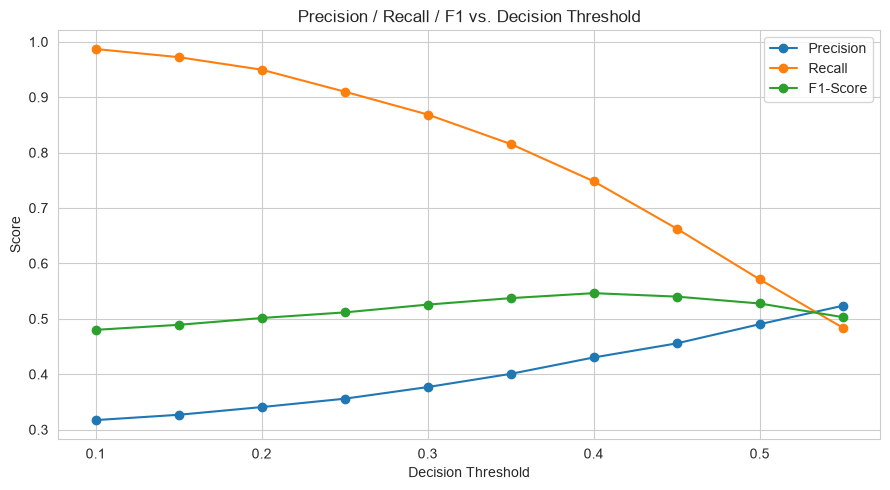

,Threshold,Precision,Recall,F1-Score
0,0.10,0.317215,0.986991,0.480121
1,0.15,0.326806,0.972285,0.489186
2,0.20,0.340706,0.949661,0.501493
3,0.25,0.355816,0.910068,0.511606
4,0.30,0.376840,0.868778,0.525667
5,0.35,0.400667,0.815611,0.537358
6,0.40,0.430244,0.748303,0.546356
7,0.45,0.455677,0.662896,0.540092
8,0.50,0.490291,0.571267,0.527691
9,0.55,0.523547,0.484163,0.503086


In [28]:
thresholds = np.arange(0.1, 0.6, 0.05)
threshold_results = []

for t in thresholds:
    preds_t = (tuned_proba >= t).astype(int)
    threshold_results.append({
        "Threshold": round(t, 2),
        "Precision": precision_score(y_test, preds_t),
        "Recall": recall_score(y_test, preds_t),
        "F1-Score": f1_score(y_test, preds_t),
    })

threshold_df = pd.DataFrame(threshold_results)

plt.figure(figsize=(9, 5))
plt.plot(threshold_df["Threshold"], threshold_df["Precision"], marker="o", label="Precision")
plt.plot(threshold_df["Threshold"], threshold_df["Recall"], marker="o", label="Recall")
plt.plot(threshold_df["Threshold"], threshold_df["F1-Score"], marker="o", label="F1-Score")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Precision / Recall / F1 vs. Decision Threshold")
plt.legend()
plt.tight_layout()
plt.show()

threshold_df

In [29]:
BEST_THRESHOLD = float(threshold_df.loc[threshold_df["F1-Score"].idxmax(), "Threshold"])
print(f"Selected operating threshold: {BEST_THRESHOLD}")

final_preds = (tuned_proba >= BEST_THRESHOLD).astype(int)
print("\nFinal performance at chosen threshold:")
print(classification_report(y_test, final_preds, target_names=["Non-Hazardous", "Hazardous"]))

Selected operating threshold: 0.4

Final performance at chosen threshold:
               precision    recall  f1-score   support

Non-Hazardous       0.97      0.89      0.93     16400
    Hazardous       0.43      0.75      0.55      1768

     accuracy                           0.88     18168
    macro avg       0.70      0.82      0.74     18168
 weighted avg       0.92      0.88      0.89     18168



---
## Phase 5: Explainability & Visualization

### 5.1 Confusion Matrix

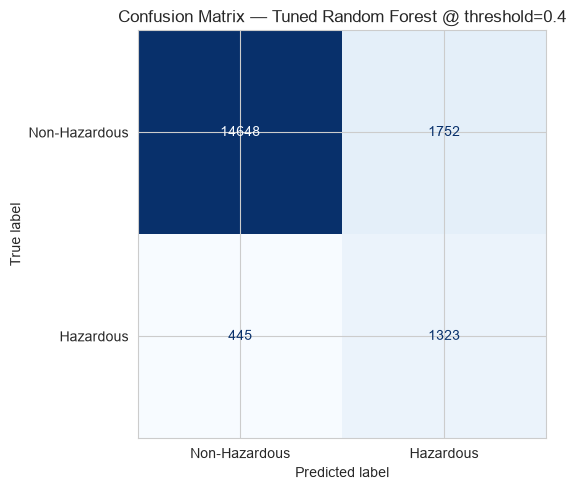

In [30]:
cm = confusion_matrix(y_test, final_preds)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Hazardous", "Hazardous"])
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title(f"Confusion Matrix — Tuned Random Forest @ threshold={BEST_THRESHOLD}")
plt.tight_layout()
plt.show()

### 5.2 ROC Curve & Precision-Recall Curve

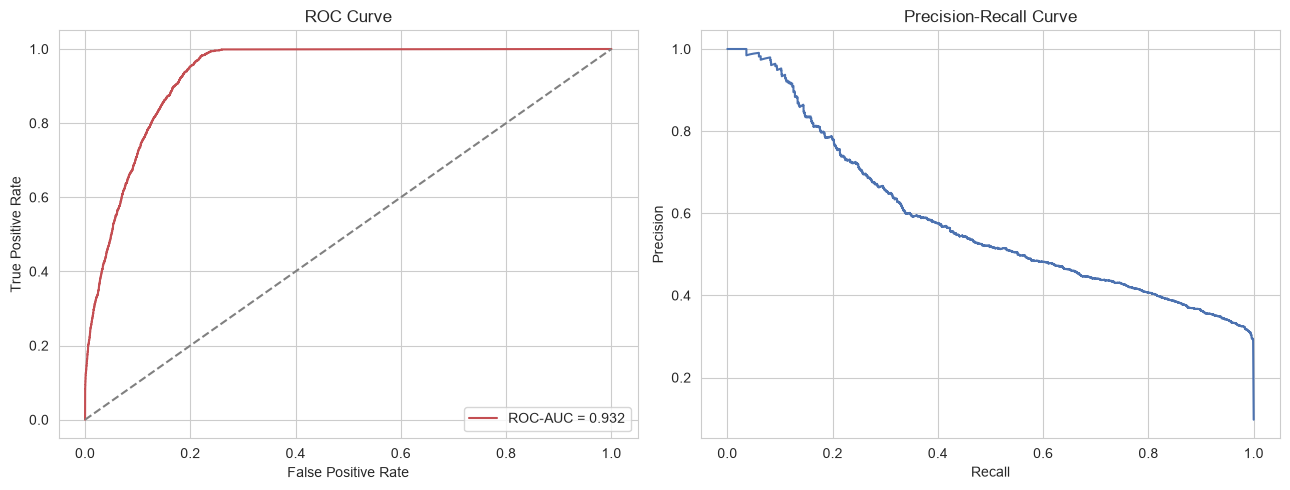

In [31]:
fpr, tpr, _ = roc_curve(y_test, tuned_proba)
prec, rec, _ = precision_recall_curve(y_test, tuned_proba)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(fpr, tpr, label=f"ROC-AUC = {roc_auc_score(y_test, tuned_proba):.3f}", color="#C44E52")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve")
axes[0].legend()

axes[1].plot(rec, prec, color="#4C72B0")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve")

plt.tight_layout()
plt.show()

### 5.3 Feature Importance (Model-Based)

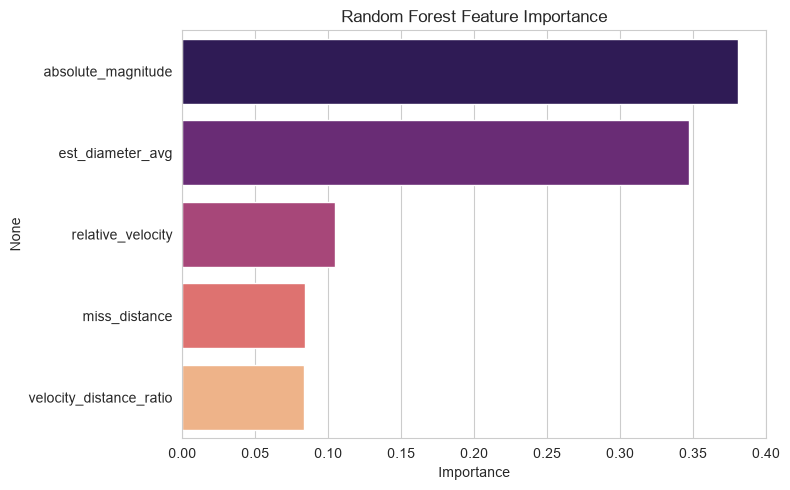

absolute_magnitude         0.381043
est_diameter_avg           0.347319
relative_velocity          0.104645
miss_distance              0.083938
velocity_distance_ratio    0.083056
dtype: float64

In [32]:
feat_importance = pd.Series(best_model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=feat_importance.values, y=feat_importance.index, palette="magma")
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

feat_importance

### 5.4 Permutation Importance (Model-Agnostic)

Permutation importance measures how much performance drops when a feature's values are randomly shuffled — it validates the built-in importances above with an independent method.

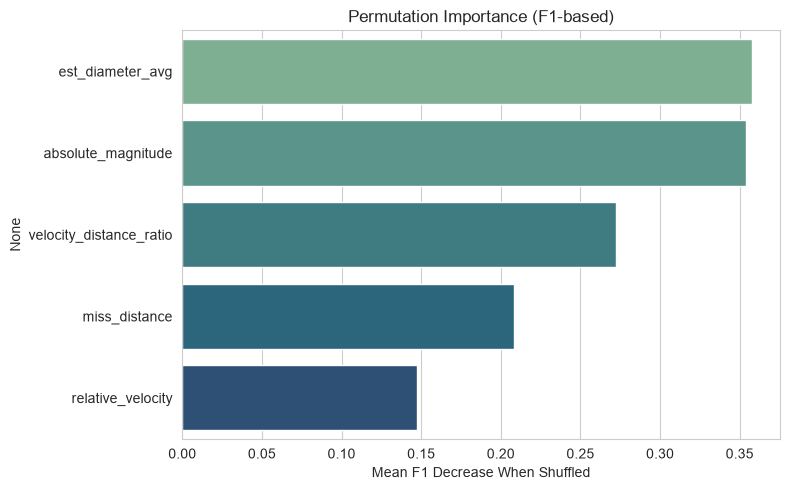

est_diameter_avg           0.357422
absolute_magnitude         0.354144
velocity_distance_ratio    0.272384
miss_distance              0.208182
relative_velocity          0.147481
dtype: float64

In [33]:
perm_result = permutation_importance(
    best_model, X_test_scaled, y_test, n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1, scoring="f1"
)
perm_importance = pd.Series(perm_result.importances_mean, index=FEATURE_COLS).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=perm_importance.values, y=perm_importance.index, palette="crest")
plt.title("Permutation Importance (F1-based)")
plt.xlabel("Mean F1 Decrease When Shuffled")
plt.tight_layout()
plt.show()

perm_importance

### 5.5 Scientific Interpretation

- **`absolute_magnitude`** and **`est_diameter_avg`** are consistently the strongest predictors — this matches physical intuition: brighter/lower-magnitude objects are larger, and larger objects pose greater impact risk.
- **`relative_velocity`** contributes meaningfully: faster-moving objects are harder to deflect and deliver more kinetic energy on impact.
- **`miss_distance`** and the engineered **`velocity_distance_ratio`** contribute secondary, refining signal — consistent with the assignment's premise that **no single feature** determines hazard status, but a combination does.
- This supports NASA's real-world criteria for Potentially Hazardous Asteroids (PHAs), which are officially defined using a combination of **minimum orbit intersection distance** and **absolute magnitude/size**.

---
## Phase 6: Deployment

### 6.1 Save the Final Trained Model

In [34]:
joblib.dump(best_model, "hazardous_asteroid_model.pkl")
joblib.dump(scaler, "feature_scaler.pkl")
joblib.dump(FEATURE_COLS, "feature_columns.pkl")
joblib.dump(BEST_THRESHOLD, "decision_threshold.pkl")

print("Saved: hazardous_asteroid_model.pkl, feature_scaler.pkl, feature_columns.pkl, decision_threshold.pkl")

Saved: hazardous_asteroid_model.pkl, feature_scaler.pkl, feature_columns.pkl, decision_threshold.pkl


### 6.2 Prediction Function

This function takes raw asteroid characteristics, applies the **exact same preprocessing** used during training (feature engineering + scaling), and returns a Hazardous / Non-Hazardous prediction with a probability score.

In [35]:
def predict_hazard(absolute_magnitude, est_diameter_min, est_diameter_max,
                    relative_velocity, miss_distance, threshold=None):
    """
    Predict whether a Near Earth Object is Hazardous or Non-Hazardous.

    Parameters
    ----------
    absolute_magnitude : float   -- brightness/size proxy (H)
    est_diameter_min    : float  -- estimated minimum diameter (km)
    est_diameter_max    : float  -- estimated maximum diameter (km)
    relative_velocity   : float  -- relative velocity (km/h)
    miss_distance       : float  -- miss distance from Earth (km)
    threshold           : float  -- optional custom decision threshold (default: tuned BEST_THRESHOLD)

    Returns
    -------
    (label, probability) : (str, float)
    """
    if threshold is None:
        threshold = BEST_THRESHOLD

    est_diameter_avg = (est_diameter_min + est_diameter_max) / 2
    velocity_distance_ratio = relative_velocity / miss_distance

    row = pd.DataFrame([[absolute_magnitude, est_diameter_avg, relative_velocity,
                          miss_distance, velocity_distance_ratio]], columns=FEATURE_COLS)

    row_scaled = scaler.transform(row)
    probability = best_model.predict_proba(row_scaled)[0][1]
    label = "Hazardous" if probability >= threshold else "Non-Hazardous"
    return label, probability


# --- Example predictions ---
examples = [
    {"absolute_magnitude": 16.0, "est_diameter_min": 1.0, "est_diameter_max": 2.5,
     "relative_velocity": 60000, "miss_distance": 2_000_000},
    {"absolute_magnitude": 24.0, "est_diameter_min": 0.02, "est_diameter_max": 0.05,
     "relative_velocity": 15000, "miss_distance": 60_000_000},
]

for ex in examples:
    label, prob = predict_hazard(**ex)
    print(f"Input: {ex}")
    print(f" -> Prediction: {label}  (probability of hazard: {prob:.2%})\n")

Input: {'absolute_magnitude': 16.0, 'est_diameter_min': 1.0, 'est_diameter_max': 2.5, 'relative_velocity': 60000, 'miss_distance': 2000000}
 -> Prediction: Hazardous  (probability of hazard: 98.62%)

Input: {'absolute_magnitude': 24.0, 'est_diameter_min': 0.02, 'est_diameter_max': 0.05, 'relative_velocity': 15000, 'miss_distance': 60000000}
 -> Prediction: Non-Hazardous  (probability of hazard: 0.00%)



### 6.3 Simple Interactive User Interface

If `ipywidgets` is installed, an interactive form is shown below. Otherwise, the notebook falls back to the plain `predict_hazard(...)` function above — so this cell **never raises an error**, regardless of environment.

In [36]:
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output

    mag_input = widgets.FloatText(value=18.0, description="Abs. Magnitude:")
    dmin_input = widgets.FloatText(value=0.1, description="Diameter Min (km):")
    dmax_input = widgets.FloatText(value=0.3, description="Diameter Max (km):")
    vel_input = widgets.FloatText(value=30000.0, description="Velocity (km/h):")
    dist_input = widgets.FloatText(value=5_000_000.0, description="Miss Dist. (km):")
    predict_button = widgets.Button(description="Predict Hazard", button_style="danger")
    output_box = widgets.Output()

    def on_predict_click(b):
        with output_box:
            clear_output()
            label, prob = predict_hazard(
                mag_input.value, dmin_input.value, dmax_input.value,
                vel_input.value, dist_input.value
            )
            emoji = "⚠️" if label == "Hazardous" else "✅"
            print(f"{emoji} Prediction: {label}")
            print(f"Probability of being hazardous: {prob:.2%}")

    predict_button.on_click(on_predict_click)

    ui = widgets.VBox([mag_input, dmin_input, dmax_input, vel_input, dist_input, predict_button, output_box])
    display(ui)

except ImportError:
    print("ipywidgets is not installed — using the text-based predictor instead.")
    print("Install with:  pip install ipywidgets\n")

    label, prob = predict_hazard(
        absolute_magnitude=18.0, est_diameter_min=0.1, est_diameter_max=0.3,
        relative_velocity=30000.0, miss_distance=5_000_000.0
    )
    print(f"Example prediction -> {label} (probability: {prob:.2%})")
    print("\nCall predict_hazard(absolute_magnitude, est_diameter_min, est_diameter_max,")
    print("                     relative_velocity, miss_distance) with your own values to try more.")

### 6.4 Reloading the Model (Simulating Production Use)

This demonstrates that the saved artifacts can be reloaded independently and reused for future predictions — exactly as a deployed service would do.

In [37]:
loaded_model = joblib.load("hazardous_asteroid_model.pkl")
loaded_scaler = joblib.load("feature_scaler.pkl")
loaded_features = joblib.load("feature_columns.pkl")
loaded_threshold = joblib.load("decision_threshold.pkl")

sample = X_test.iloc[[0]]
sample_scaled = loaded_scaler.transform(sample)
sample_proba = loaded_model.predict_proba(sample_scaled)[0][1]
sample_label = "Hazardous" if sample_proba >= loaded_threshold else "Non-Hazardous"

print("Reloaded model prediction on a test sample:")
print(f" -> {sample_label} (probability: {sample_proba:.2%}), true label: "
      f"{'Hazardous' if y_test.iloc[0]==1 else 'Non-Hazardous'}")

Reloaded model prediction on a test sample:
 -> Non-Hazardous (probability: 25.17%), true label: Non-Hazardous


---
## Summary

| Phase | What was done |
|---|---|
| 1. Preprocessing | Loaded data, checked/handled missing values & duplicates, dropped uninformative columns (`id`, `name`, `orbiting_body`, `sentry_object`), encoded the boolean target |
| 2. EDA | Visualized class imbalance (~9.7% hazardous), feature distributions, boxplots by class, correlation heatmap, and multi-feature scatter relationships |
| 3. Feature Engineering | Created `est_diameter_avg` and `velocity_distance_ratio`; removed perfectly-redundant `est_diameter_min`/`max`; ranked features by mutual information |
| 4. Modeling | Trained Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting with `class_weight="balanced"`; tuned Random Forest via `RandomizedSearchCV`; tuned the decision threshold for recall-sensitive detection |
| 5. Explainability | Confusion matrix, ROC & Precision-Recall curves, built-in and permutation feature importance, scientific interpretation |
| 6. Deployment | Saved model/scaler/threshold with `joblib`; built a reusable `predict_hazard()` function; added an `ipywidgets` UI with a safe text-based fallback |

**Final model:** Tuned Random Forest Classifier, selected for the best balance of ROC-AUC, recall on the hazardous class, and interpretability via feature importances.